# Text Analytics
## Assignment on N-Grams Models

- Georgios Boufis, *f3352504*, *geo.boufis@aueb.gr*
- Leonidha Mara, *f3352514*, *leo.mara@aueb.gr*

## 1) Implemenation of Ngram Models

In [ ]:
!pip install nltk

In [ ]:

# numpy stack : standard tools for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# general : utilities for regex, math, and string normalization
import re
import math
import random
import unicodedata
import string
from collections import Counter
from pprint import pprint
import sys

# nltk : core NLP library for corpora and n-gram generation
import nltk
from nltk.util import ngrams
from nltk.corpus import gutenberg
from nltk.corpus import webtext

# # others : fuzzy string matching and specialized math functions
# !pip install fuzzywuzzy
# from fuzzywuzzy import fuzz
# from scipy.special import softmax

# ensure that all plots are rendered directly within the notebook
%matplotlib inline


In [ ]:
# Downloading the Gutenberg corpus (a collection of free e-books)
nltk.download("gutenberg")

# Downloading the 'punkt' and 'punkt_tab' tokenizers for sentence splitting and word tokenization
nltk.download("punkt_tab")
nltk.download("punkt")


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

**Data Acquisition: The Gutenberg Corpus**

We begin by accessing the Gutenberg Corpus, which provides a  set of literary texts. We identify  the available files at the first step in selecting the specific data we will analyze for our language modeling. We will see below that we retrieve all the fileids which are available in the Gutenberg corpus in a form of the list and then we will print the first three files in order to see if we access it correctly. We observe from the output that the first 3 fileids are 'austen-emma.txt', 'austen-persuasion.txt' and 'austen-sense.txt'.

In [ ]:
# Retrieve the list of all file identifiers available in the Gutenberg corpus
gutenberg_files_id = nltk.corpus.gutenberg.fileids()

# Preview the first three file IDs to verify successful access
gutenberg_files_id[:3]


['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt']

**Initial Data Inspection**

To see and understand the raw structure of our corpus, we perform a preliminary inspection of the first text. This allows us to observe the punctuation and capitalization which will inform our subsequent tokenization and cleaning strategies. So from the following block of code what we do is to print the first sentence of the first file of corpus and we can observe that there are punctuations and capital letters which we have to process carefully.
This check is vital for designing an effective cleaning pipeline, as it reveals how the text is naturally organized.

In [ ]:
gutenberg.raw(gutenberg_files_id[0]).split('.')[0] # Print the first sentence of the first file

'[Emma by Jane Austen 1816]\n\nVOLUME I\n\nCHAPTER I\n\n\nEmma Woodhouse, handsome, clever, and rich, with a comfortable home\nand happy disposition, seemed to unite some of the best blessings\nof existence; and had lived nearly twenty-one years in the world\nwith very little to distress or vex her'

**Text Preprocessing Strategy**

Before performing any statistical analysis, we must clean the raw text to ensure consistency. The Gutenberg corpus contains several non-linguistic elements,such as metadata and artifacts,that could skew our results if not handled correctly.


**Corpus Aggregation and Normalization**

To build a robust language model, we concentrate  all individual documents from the Gutenberg corpus into a single text string. During this process, we apply lowercasing.

By converting to lowercase, we ensure that words like "The" and "the" are treated as the same token. This prevents the model from splitting the probability  between identical words that only differ in capitalization due to their position in a sentence.

N-gram models suffer from the vocabulary sparsity. The fact that many valid word sequences never appear in the training data. Aggregating all  books significantly increases our N-gram counts, providing more reliable statistical evidence for infrequent sequences and reducing the number of zero-count transitions.

In [ ]:
# Initialize an empty string to hold the entire aggregated corpus
corpus_to_text = ""

# Iterate through each file in the Gutenberg collection
for corpus in gutenberg_files_id :
  # Retrieve the raw text of the current file
  text = gutenberg.raw(fileids = corpus)
  # Normalize text to lowercase to ensure consistency across the vocabulary
  lower_text = text.lower()
  # Append the processed text to our main string
  corpus_to_text += lower_text

**Quantifying Noise in the Raw Corpus**:
 We perform an audit of the aggregated raw text. By using regular expressions to count specific non-linguistic patterns, we can justify the complexity of our preprocessing pipeline and understand the magnitude of the artifacts we are removing.
 1. **Verse References** (31,102 occurrences): This is a staggering amount of noise. If left untouched these numerical references would create thousands of irrelevant unique tokens, significantly inflating the vocabulary and diluting the probability mass of actual words.
 2. **Structural Headers** (428 occurrences): While the count is lower, these terms (like "Volume I") are highly repetitive and would lead the model to falsely assume that "Volume" is a key narrative word.
 3. **Whitespace & Newlines** (~325,000 occurrences combined): The raw corpus is riddled with formatting artifacts. Normalizing these is essential for maintaining text continuity and ensuring the tokenizer doesn't break words or sentences incorrectly.

In [ ]:
# references (e.g., '1:1', '12:3')
# These are highly frequent in religious texts like the Bible
pattern = re.compile(r'\b\d+:\d+\b')
matches = pattern.findall(corpus_to_text)
print(f"Occurrences of {matches[:2]} in raw text: {len(matches)}/{len(corpus_to_text)}")

# Metadata and illustration tags in brackets
pattern = re.compile(r'\[.*?\]')
matches = pattern.findall(corpus_to_text)
print(f"Occurrences of {matches[:2]} in raw text: {len(matches)}/{len(corpus_to_text)}")

#Structural markers (Chapter, Volume, Book, etc.)
pattern = re.compile(r'(?i)\b(chapter|volume|book|part|page|no)\.?\s+([ivxlcdm]+|\d+)\b\.?')
matches = pattern.findall(corpus_to_text)
print(f"Occurrences of {matches[:2]} in raw text: {len(matches)}/{len(corpus_to_text)}")

# Newlines and Carriage Returns
pattern = re.compile(r'[\r\n]+')
matches = pattern.findall(corpus_to_text)
print(f"Occurrences of {matches[:2]} in raw text: {len(matches)}/{len(corpus_to_text)}")

# Remove emphasis markers such as underscores and asterisks (italics/bold)
pattern = re.compile('[_*]')
matches = pattern.findall(corpus_to_text)
print(f"Occurrences of {matches[:2]} in raw text: {len(matches)}/{len(corpus_to_text)}")

# Collapse multiple whitespace characters into a single space for uniform spacing
pattern = re.compile(r'\s{2,}')
matches = pattern.findall(corpus_to_text)
print(f"Occurrences of {matches[:2]} in raw text: {len(matches)}/{len(corpus_to_text)}")



Occurrences of ['1:1', '1:2'] in raw text: 31102/11793318
Occurrences of ['[emma by jane austen 1816]', '[to mrs. weston.]'] in raw text: 118/11793318
Occurrences of [('volume', 'i'), ('chapter', 'i')] in raw text: 428/11793318
Occurrences of ['\n\n', '\n\n'] in raw text: 206442/11793318
Occurrences of ['_', '_'] in raw text: 1399/11793318
Occurrences of ['\n\n', '\n\n'] in raw text: 119096/11793318


Our cleaning pipeline follows these logical steps:
1. **Metadata Removal**: By using a match (.*?), we ensure that we only remove the content inside the brackets and not everything between the first and last bracket of the entire book.
2. **Whitespace Normalization**:Replacing \n and \r with spaces prevents the tokenizer from treating line breaks as sentence terminators or word breaks.
3. **Structural Integrity**: Removing "Chapter" and "Volume" markers is essential because these words are structural, not narrative. Without this, "Chapter" would incorrectly rank as a top-frequency Unigram.
4. **Uniformity**: The final step (\s+ replacement) ensures that our entire corpus is a single, clean sequence of tokens separated by exactly one space, which is the optimal state for N-gram generation.
5. **Removing the format num:num** : By removing this format we ensure the vocabulary remains focused on literary content. This prevents the model from incorrectly learning that numbers are "keywords" in the narrative.

In [ ]:
def clean_gutenberg_text(text):
   # Remove metadata or illustration tags contained within brackets
    text = re.sub(r'\[.*?\]', '', text)

    # remove num:num
    text = re.sub(r'\b\d+:\d+\b', '', text)

    # remove chapter IV / volume i
    text = re.sub(r'(?i)\b(chapter|volume)\s+([ivxlcdm]+|\d+)\b\.?', '', text)

    # Replace Newlines and carriage returns with spaces to maintain text continuity
    text = text.replace('\n', ' ').replace('\r', ' ')

    # Remove emphasis markers such as underscores and asterisks (italics/bold)
    text = text.replace('_', '').replace('*', '')

    # Collapse multiple whitespace characters into a single space for uniform spacing
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

Since we complete the aggregation, we now apply the **clean_gutenberg_text** function to the entire consolidated corpus. This step finalizes our data preparation by removing non-linguistic noise and structural artifacts, ensuring that our subsequent n-gram analysis is based on actual literary content rather than metadata or formatting symbols.

In [ ]:
cleaned_text = clean_gutenberg_text(corpus_to_text)

Now, we print the first 1000 characters in order to see if we remove the specific punctuations and whitespaces we wanted to remove from the start.

In [ ]:
print(cleaned_text[:1000])

emma woodhouse, handsome, clever, and rich, with a comfortable home and happy disposition, seemed to unite some of the best blessings of existence; and had lived nearly twenty-one years in the world with very little to distress or vex her. she was the youngest of the two daughters of a most affectionate, indulgent father; and had, in consequence of her sister's marriage, been mistress of his house from a very early period. her mother had died too long ago for her to have more than an indistinct remembrance of her caresses; and her place had been supplied by an excellent woman as governess, who had fallen little short of a mother in affection. sixteen years had miss taylor been in mr. woodhouse's family, less as a governess than a friend, very fond of both daughters, but particularly of emma. between them it was more the intimacy of sisters. even before miss taylor had ceased to hold the nominal office of governess, the mildness of her temper had hardly allowed her to impose any restrai

We will see that because of the cleaning proccess we remove specific characters that we wanted to be removed from the text, we observe that the characters on the cleaned text are significantly lower than the characters on the raw text, the difference is around 175.000 characters.

In [ ]:
print(f"Characters on cleaned text: {len(cleaned_text)}\
      \n vs raw text: {len(corpus_to_text)}")

Characters on cleaned text: 11448996      
 vs raw text: 11793318


**Utility Function for Data Verification**

To help the inspection of our processed data, we define a helper function **print_sents**. This allows us to preview a specific number of sentences from our corpus, separated by clear visual boundaries. This is a crucial step for quality control, ensuring that our preprocessing and future tokenization align with our expectations.

In [ ]:
def print_sents(sents, n_first = None) :
  if n_first is not None :
    sents = sents[:n_first]
  for sent in sents :
    print(sent)
    print("_______")

**Splitting the Text into Sentences**

Now that the text is clean, the next step is to break it down into sentences. We are using **NLTK's sent_tokenize** for this.

Sentence tokenization is vital for language modeling because it allows us to treat each sentence as an independent unit of meaning. This enables the subsequent insertion of ***start*** and ***end*** tokens, which teach the model how a thought typically begins and concludes.

This helps keep the context clear.After splitting them, we are using the helper function we wrote earlier to print the first three sentences just to make sure everything looks right.

The output shows that the first three sentences have been correctly identified. We notice that long, complex sentences are kept intact, ensuring that our N-grams will capture the syntactic dependencies within these structures.

In [ ]:
from nltk import sent_tokenize

# Use the sent_tokenize function to split our big string into a list of sentences
sentences = sent_tokenize(cleaned_text)

print_sents(sentences, 3)

emma woodhouse, handsome, clever, and rich, with a comfortable home and happy disposition, seemed to unite some of the best blessings of existence; and had lived nearly twenty-one years in the world with very little to distress or vex her.
_______
she was the youngest of the two daughters of a most affectionate, indulgent father; and had, in consequence of her sister's marriage, been mistress of his house from a very early period.
_______
her mother had died too long ago for her to have more than an indistinct remembrance of her caresses; and her place had been supplied by an excellent woman as governess, who had fallen little short of a mother in affection.
_______


**Designing a Custom Tokenizer**

Now I need to split the sentences into individual words (tokens). Instead of using a simple split, I'm creating a custom **RegexpTokenizer**. By using **RegexpTokenizer** we ensure that our frequency counts are accurate.

It looks for words that might have an apostrophe or a dash in the middle (like it's or well-known) and keeps them as one token.


It treats punctuation marks as their own separate tokens. This is important because, in a language model, a comma or a period is a meaningful "signal" that a sentence structure is changing.

A simple split would often break words like "well-known" or "it's" into separate, confusing fragments. Our pattern **\w+(?:['’-]\w+)*** treats these as single tokens, preserving their semantic meaning and ensuring they are counted correctly in Bigram and Trigram sequences.

This level of control ensures that our vocabulary is clean and that "don't" (single token) isn't accidentally mixed with "don" and "t" (two tokens), which would affect our vocabulary size.


In [ ]:
from nltk.tokenize import RegexpTokenizer


# \w+            : Matches the first part of a word (alphanumeric)
# (?:['’-]\w+)*  : Matches optional repetitions of an apostrophe or dash followed by more letters
# |              : Or
# [^\w\s]        : Matches any single punctuation mark or symbol (anything not a word or whitespace)

pattern = r"\w+(?:['’-]\w+)*|[^\w\s]"

# Initialize the tokenizer with our custom regex pattern
tokenizer = RegexpTokenizer(pattern)


**Building the Tokenized Corpus**

Now that the custom tokenizer is ready, we are applying it to every sentence in the collection. This turns our text into a nested list structure, where each item is a sentence, and each sentence is a list of individual words and punctuation marks.

1. We loop through each sentence.
2. We use the **tokenizer.tokenize** method to break it down based on our custom rules.
3. We add an if tokens: check just in case there are any empty strings or weird whitespace issues, so we don't have empty sentences in my final data.

Also, we can see from the output that all the sentences were tokenized successfully, meaning no data was lost during this structural transformation.

Finally, we are printing the counts and a sample sentence to make sure the "word-splitting" logic worked as expected before moving on to the analysis.



In [ ]:
tokenized_corpus = []

# Process each sentence one by one
for sent in sentences:
  # Split the sentence into tokens using our custom RegexpTokenizer
  tokens = tokenizer.tokenize(sent)

  # Only add the list of tokens if it is not empty
  if tokens:
    tokenized_corpus.append(tokens)

print("Num sentences:", len(sentences))
print("Num tokenized sentences:", len(tokenized_corpus))
print("Example tokenized sentence:", tokenized_corpus[0][:100])

Num sentences: 94172
Num tokenized sentences: 94172
Example tokenized sentence: ['emma', 'woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', '.']


**Data Splitting: Training and Development Sets**

Before we start building any models, we need to split our data into different subsets. We are doing this to make sure that we can train the model on the training set and then test it on "unseen" data to see how well it actually performs.

We use **random.shuffle** to mix the sentences. This is important because the Gutenberg corpus has different books, if we didn't shuffle our training set might only have e.g Jane Austen and my test set might only have Shakespeare.

We set a **random.seed(1)**. This ensures that every time we run this code, we get the same shuffle, which makes our results consistent.

We've decided to use 60% of the data for Training and 20% for the Development set. The remaining 20% will be saved for the final testing later on.







In [ ]:

random.seed(1)

# Create a copy of the tokenized corpus to avoid modifying the original list
data = tokenized_corpus[:]
random.shuffle(data)

# Calculate the split points
train_length = math.floor(0.6 * len(data))
dev_length   = math.floor(0.2 * len(data))



**Finalizing the Split**

Now that we have calculated the split points, we are slicing the data into three distinct sets: **Train**, **Development** (**Dev**), and **Test**.



*   **Train**: Used to teach the model
*   **Dev**: Used to tune the hyper-parameter and check progress.
*   **Test**: Used at the end to see how the model handles completely new text.

We are also printing out the sizes of each set and a quick example just to be 100% sure that everything was sliced correctly and the data remains in its tokenized form.

From the output we observe that our total corpus of 94,172 sentences has been distributed as 56,503 (Train), 18,834 (Dev), and 18,835 (Test). The counts sum perfectly to our original total, ensuring no data was lost or duplicated during the split.


In [ ]:
train_sents = data[:train_length]
dev_sents   = data[train_length:train_length + dev_length]
test_sents  = data[train_length + dev_length:]

# Print the number of sentences in each split to verify the math
print(f"Train: {len(train_sents)}\nDev: {len(dev_sents)}\nTest: {len(test_sents)}")

# Preview a small part of a training sentence to verify the data structure
print("Example TRAIN sentence:", train_sents[2][:20])

Train: 56503
Dev: 18834
Test: 18835
Example TRAIN sentence: ['must', 'we', 'barely', 'arrive', 'at', 'this', 'beginning', 'of', 'us', '?']


**Vocabulary Building and Out-of-Vocabulary (OOV) Handling**

Now we need to decide which words our model will actually "know." If we include every single word that appears only once, our model will become too large and inefficient.

1. **Count only the Training data**: It is very important to only look at the train_sents. If we looked at the Test data now, we would be "cheating" by knowing the future.

2. **Frequency Threshold (MIN_COUNT)**: We have set a limit of 10. Any word that appears fewer than 10 times is considered too rare to learn reliable patterns from and we define them as "UNK".

3. The ***UNK* Token**: For all those rare words, we are creating a special category called *UNK* (Unknown). This way, when the model sees a new word later, it knows how to handle it instead of crashing.

4. The ***end* Token**: We are also adding a marker to signify the end of a sentence, which is crucial for the model to learn when to stop generating text.


From the output, we can observe that by using the threshold we reduced significantly the size of the Vocabulary from 38763 to 7483. Also we can see that the most usual tokens in the training set are the commas, the word "the", the word "and" and the fullstop, which is normal since gutenberg is a literacy corpus.

In [ ]:
from collections import Counter

MIN_COUNT = 10

# Count tokens in TRAIN only
train_token_counts = Counter()
for sent in train_sents:
    train_token_counts.update(sent)

# Build vocabulary: keep tokens with count >= MIN_COUNT
vocab = {tok for tok, c in train_token_counts.items() if c >= MIN_COUNT}

# Add UNK explicitly
vocab.add("*UNK*")
vocab.add("*end*")

print("Train unique tokens (before threshold):", len(train_token_counts))
print("Vocab size (after threshold + UNK):", len(vocab))

# Show a few examples
print("Most common tokens in TRAIN:", train_token_counts.most_common(10))


Train unique tokens (before threshold): 38573
Vocab size (after threshold + UNK): 7348
Most common tokens in TRAIN: [(',', 115090), ('the', 80324), ('and', 57078), ('.', 49095), ('of', 42929), ('to', 28581), ('a', 20324), ('in', 20054), ('"', 18702), ('i', 17446)]


**Handling Out-of-Vocabulary (OOV) Words**

Now that we have my fixed vocabulary, we need to go back through our datasets and replace every word that isn't in the vocab with our special ***UNK*** tag.

1. **Consistency**: The model can only calculate probabilities for words it has seen enough times. By grouping all rare words into *UNK*.

2. **Fair Testing**: We apply this to the Dev and Test sets too. If a word appears in the Test set that was never in our Training vocabulary, the model won't crash; it will simply treat it as an *UNK*.

After the replacement, we are counting how many *UNK* tokens appeared in each split. Seeing a higher number of unknowns in the Test set is normal because it contains text the vocabulary-building process never saw.
Also, from the output we can see that words like "reeling" and "teetering" were replaced by ***UNK***. This proves that these specific words appeared fewer than 10 times in our training set.

In [ ]:
def replace_oov_dataset(dataset, vocab):
    new_dataset = []
    for sent in dataset:
        # For every word, keep it if it's in vocab, otherwise use *UNK*
        new_sent = [tok if tok in vocab else "*UNK*" for tok in sent]
        new_dataset.append(new_sent)
    return new_dataset

# Apply the replacement function to all three data splits
train_sents_unk = replace_oov_dataset(train_sents, vocab)
dev_sents_unk   = replace_oov_dataset(dev_sents, vocab)
test_sents_unk  = replace_oov_dataset(test_sents, vocab)


print("Example before:", train_sents[13][:20])
print("Example after :", train_sents_unk[13][:20])

# how many UNKs appeared?
unk_count_train = sum(tok == "*UNK*" for sent in train_sents_unk for tok in sent)
unk_count_dev   = sum(tok == "*UNK*" for sent in dev_sents_unk for tok in sent)
unk_count_test  = sum(tok == "*UNK*" for sent in test_sents_unk for tok in sent)

print("UNK count (train/dev/test):", unk_count_train, unk_count_dev, unk_count_test)


Example before: ['a', 'great', 'rolling', 'sea', ',', 'dashing', 'high', 'up', 'against', 'the', 'reeling', "ship's", 'high', 'teetering', 'side', ',', 'stove', 'in', 'the', "boat's"]
Example after : ['a', 'great', 'rolling', 'sea', ',', 'dashing', 'high', 'up', 'against', 'the', '*UNK*', "ship's", 'high', '*UNK*', 'side', ',', 'stove', 'in', 'the', "boat's"]
UNK count (train/dev/test): 73628 25886 26680


**Building the N-gram Models (Unigram, Bigram, and Trigram)**

Now that the data is cleaned and the vocabulary is set, we are building the  languange models, Unigram, Bigram, and Trigram.

When predicting words, the model needs to know how sentences typically start and end. We are adding special padding symbols to help with this:
1. **Unigram**: We add ***start*** and ***end*** to get a general count of how often sentences begin and conclude.
2. **Bigram**: By using pad_left and pad_right, we create pairs like (*start*, first_word) and (last_word, *end*)
3. **Trigram**: For trigram, we use two start symbols (*start1*, *start2*) because predicting the third word requires looking back at the previous two.

We’ll notice that even the Unigrams are stored as tuples (e.g., ('the',)). This is happening because it keeps the data format consistent across all models (1-tuple for Unigrams, 2-tuple for Bigrams, 3-tuple for Trigrams), making the probability functions much easier to write later.


In [ ]:
from tqdm import tqdm

# Initialize counters for our three different models
unigram_counter = Counter()
bigram_counter = Counter()
trigram_counter = Counter()

# Loop through the training data with a progress bar
for sent in tqdm(train_sents_unk):
    #Update Unigrams: Adding start and end markers to count word frequency in context
    unigram_counter.update([(gram,) for gram in ["*start*"] + sent + ["*end*"]])
    # Update Bigrams: Using NLTK's ngrams with padding to capture word pairs
    bigram_counter.update([gram for gram in ngrams(sent, 2, pad_left=True, pad_right=True,
                                                   left_pad_symbol='*start*',right_pad_symbol='*end*') ])
    # Update Trigrams: Manually padding with two start symbols for 3-word sequence counting
    trigram_counter.update([gram for gram in ngrams(["*start1*"] +["*start2*"]+ sent + ["*end*"], 3, pad_left=False, pad_right=False)
                                                     ])



100%|██████████| 56503/56503 [00:04<00:00, 13049.52it/s]


**Statistical Inspection of N-gram Frequencies**

Before we calculate the final probabilities, we need to inspect the raw counts to make sure the N-grams make sense.

* **Unigram**: The most common word,punctuation as we can see from the output are the comma and the word "the". This is expected in almost any English corpus.

* **Bigram and Trigram**: We can  see that  the most common sequences are natural English patterns, like ('.', '*end*') for the bigram and ('*start1*', '*start2*', '"') for the trigram.

* **Total Token Count**: We calculate the total number of unigrams (N_tokens), which is useful for calculating the general probability of any single word appearing.

In [ ]:
# Calculate the total number of all unigrams in the training set
N_tokens = sum(unigram_counter.values())

print("Total unigram tokens:", N_tokens)
print("Top unigrams:", unigram_counter.most_common(10))
#bigram_counter[("start1", "start2")] = len(train_sents_unk)
print()
pprint(unigram_counter.most_common(25))
print()
pprint(bigram_counter.most_common(25))
print()
pprint(trigram_counter.most_common(25))
print()

Total unigram tokens: 1617944
Top unigrams: [((',',), 115090), (('the',), 80324), (('*UNK*',), 73628), (('and',), 57078), (('*start*',), 56503), (('*end*',), 56503), (('.',), 49095), (('of',), 42929), (('to',), 28581), (('a',), 20324)]

[((',',), 115090),
 (('the',), 80324),
 (('*UNK*',), 73628),
 (('and',), 57078),
 (('*start*',), 56503),
 (('*end*',), 56503),
 (('.',), 49095),
 (('of',), 42929),
 (('to',), 28581),
 (('a',), 20324),
 (('in',), 20054),
 (('"',), 18702),
 (('i',), 17446),
 (('that',), 17196),
 ((';',), 16799),
 (('he',), 15346),
 (('it',), 13049),
 (('his',), 12891),
 (('-',), 11731),
 (('for',), 11707),
 (('was',), 11258),
 (('with',), 10517),
 (('not',), 10406),
 ((':',), 10007),
 (('is',), 9857)]

[(('.', '*end*'), 41690),
 ((',', 'and'), 25807),
 (('*UNK*', ','), 14815),
 (('of', 'the'), 11401),
 (('the', '*UNK*'), 9560),
 (('*start*', 'and'), 7803),
 (('in', 'the'), 6151),
 (('*start*', '"'), 6071),
 (('"', '*end*'), 5994),
 (('-', '-'), 5893),
 (('*UNK*', '.'), 53

## 2) Cross-Entropy and Perplexity for Ngram Models

**Implementing the Bigram Language Model with Smoothing**

We have created a function called bigram_LM that evaluates how well our model "understands" a dataset. Instead of just looking at raw counts, this function uses **a-Smoothing** and calculates **Perplexity**.

In real text, we often find word pairs that never appeared in our training dataset. Without smoothing, the probability of an unseen pair would be zero, making the probability of the entire sentence zero. By adding a small value (a = 0.01), we ensure that the model can handle "surprises" without crashing.

Instead of multiplying probabilities (which would result in tiny numbers that computers can't handle well), we sum the log-probabilities.

**Cross-Entropy and Perplexity:**

1. **Cross-Entropy (HC)**:

This represents the average number of bits required to identify a word in the sequence. It measures the average "surprise" of the model.

2. **Perplexity**:

This is the final benchmark. A lower perplexity means the model is better at predicting the next word. It basically tells us: "On average, the model is as confused as if it had to choose randomly between X many words."

In [ ]:
def bigram_LM(corpus, unigram_counter, bigram_counter, V, alpha=0.01):

  bigram_cnt = 0
  sum_log_prob=0

  for sent in corpus:
      sent = ['*start*'] + sent + ['*end*']
      # Iterate over the bigrams of the sentence
      for idx in range(1, len(sent)):
      # for first_token, second_token in pairwise(sent):
          bigram_prob = (bigram_counter[(sent[idx-1], sent[idx])] + alpha) / (unigram_counter[(sent[idx-1],)] + alpha*V)
          sum_log_prob += math.log2(bigram_prob)
          bigram_cnt += 1

  HC = -sum_log_prob / bigram_cnt
  perpl = math.pow(2, HC)
  return HC, perpl

**The Trigram Language Model**

Now we are implementing the Trigram Language Model. This is a step up from the Bigram model because it predicts the next word based on the two previous words instead of just one.

By looking at sequences of three words ($w_{i-2}, w_{i-1}, w_i$), the model can capture more complex language patterns.

Because three-word sequences are rarer than two-word sequences, many trigrams will have a count of zero. This is why the Alpha Smoothing $(\alpha)$ is even more critical here; it prevents the probability from dropping to zero when the model encounters a new three-word combination.

Just like before, we use log-probabilities to calculate **Cross-Entropy** and **Perplexity** to evaluate how well this model performs compared to the Bigram one.



In [ ]:
def trigram_LM(corpus, unigram_counter, bigram_counter
               , trigram_counter,V, alpha=0.01):
  sum_prob = 0
  trigram_cnt = 0

  for sent in corpus:
      sent = ['*start1*'] + ['*start2*'] + sent + ['*end*']

      for idx in range(2, len(sent)):
          trigram_prob = (trigram_counter[(sent[idx-2], sent[idx-1], sent[idx])] + alpha) / (bigram_counter[(sent[idx-2],sent[idx-1])] + alpha*V)
          sum_prob += math.log2(trigram_prob)
          trigram_cnt+=1

  HC = -sum_prob / trigram_cnt
  perpl = math.pow(2,HC)
  return HC, perpl

**Hyper-parameter Tuning: Finding the Optimal Alpha ($\alpha$)**

We have the functions ready, but we still need to decide on the best value for $\alpha$ (the smoothing constant). If $\alpha$ is too small, we might give too much importance to rare events, if it's too large, we might wash out the actual patterns in the data.



1.  **Data Subset**: We are using a subset of the Development set. We use the Dev set for tuning and not Test set so we don't **"overfit"** our model to the training data and to ensure our final evaluation remains unbiased and free of data leakage.

2. **Range of Alphas**: We are testing 20 different values for $\alpha$, ranging from 0.01 to 1.0, using ***np.linspace***.

3. **Comparison**: For every $\alpha$ value, we calculate the Cross-Entropy and Perplexity for both the Bigram and Trigram models.

By the end of this loop, we will be able to see which $\alpha$ gives the **lowest perplexity**. This tells me which level of smoothing makes my model the most "confident" when seeing new text.



In [ ]:
dev_subset = dev_sents_unk[:]
alpha_values = []
bi_perplexity_values = []
bi_entropy_values = []
tri_perplexity_values = []
tri_entropy_values = []

for alpha in np.linspace(0.01, 1, 20):
    # Bigram
    alpha_values.append(alpha)
    HC, perpl = bigram_LM(dev_subset,
                          unigram_counter, bigram_counter,
                           len(vocab), alpha=alpha)
    bi_entropy_values.append(HC)
    bi_perplexity_values.append(perpl)

    # Trigram
    HC, perpl = trigram_LM(dev_subset, unigram_counter,
                            bigram_counter, trigram_counter,len(vocab), alpha=alpha)
    tri_entropy_values.append(HC)
    tri_perplexity_values.append(perpl)

**Visualizing the Impact of Smoothing on Model Performance**

Now that we've tested various $\alpha$ values, we are plotting the results to see how the Bigram and Trigram models compare. These graphs help us visualize the relationship between smoothing and model "uncertainty".

We observed a significant difference in how the two models react as we increase the smoothing parameter $\alpha$:
* Bigram Stability:

 The Bigram perplexity starts at ~100 and only reaches ~250 at $\alpha=1.0$.

* Trigram Volatility:

  The Trigram perplexity starts at ~200 but explodes to ~1200 at $\alpha=1.0$.

  In our corpus, there are millions of possible 3-word combinations (trigrams), but most of them appear zero times. When we use a large $\alpha$, we are essentially "guessing" and giving a lot of probability mass to these millions of non-existent trigrams. This makes the model much less certain about the real patterns it saw, causing the Perplexity goes up.

   By setting $\alpha=1.0$, we are forcing the model to act more like a "uniform" model (where every word is equally likely). Since the Trigram has a much larger "search space" of possibilities, being "uniform" makes it far more confused than the simpler Bigram model.


   Now, by looking at the Cross-Entropy plot, we can see a clear difference in how much "information" or "surprise" each model carries as we change the smoothing level:
   1. Starting Points and Complexity ($\alpha \approx 0$):
       * The Bigram starts at roughly 6.9 bits, while the Trigram starts higher, at about 7.8 bits.
       * The lower the  entropy means the model is more "certain" about its predictions. This confirms that, with minimal smoothing, the Bigram model finds the text much more predictable than the Trigram model does.
   2. As $\alpha$ increases to 1.0, the Trigram's entropy climbs sharply to 10.5 bits, while the Bigram's entropy grows more slowly, reaching only 7.8 bits.

   As a result, the Trigram model is much more sensitive to the choice of $\alpha$. Every time we increase $\alpha$, we are adding "artificial" counts to millions of possible word combinations that never actually happened. Because there are so many more possible Trigrams than Bigrams, this "noise" overwhelms the Trigram model much faster. Also, an entropy of 10.5 bits means the model is significantly more "confused." It shows that by over-smoothing the Trigram model, we are effectively destroying the real linguistic patterns it learned from the training data, turning it into a much weaker predictor.

   Finally, the fact that the Bigram's worst entropy (at $\alpha=1$) is equal to the Trigram's best entropy (at $\alpha \approx 0$) is a very strong signal. It proves that for this specific dataset and vocabulary size, the Bigram structure is fundamentally more efficient at capturing the patterns of the language than the Trigram structure.

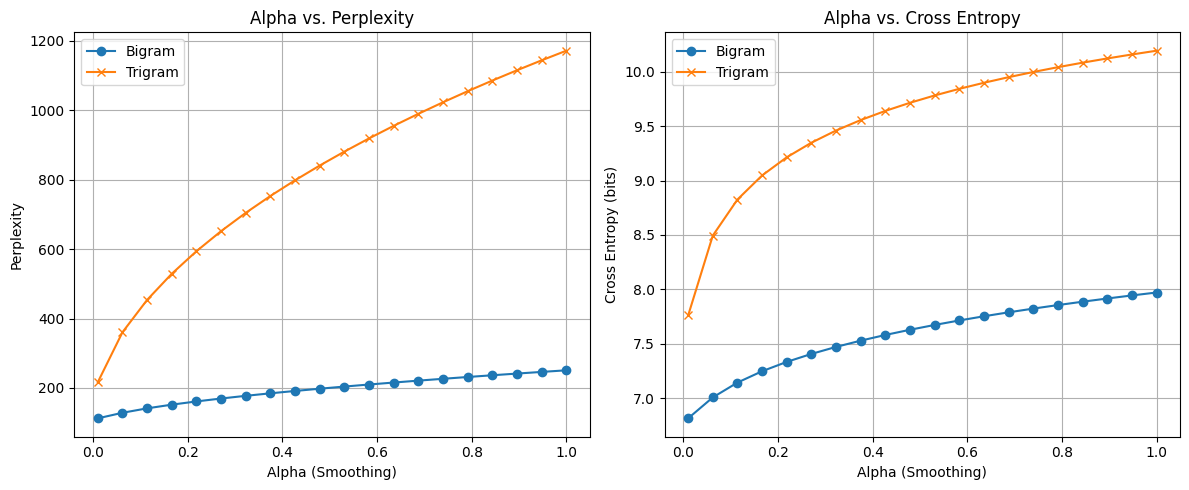

In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Perplexity
plt.subplot(1, 2, 1)
plt.plot(alpha_values, bi_perplexity_values, label='Bigram', marker='o')
plt.plot(alpha_values, tri_perplexity_values, label='Trigram', marker='x')
plt.title('Alpha vs. Perplexity')
plt.xlabel('Alpha (Smoothing)')
plt.ylabel('Perplexity')
plt.legend()
plt.grid(True)

# Plot 2: Cross Entropy
plt.subplot(1, 2, 2)
plt.plot(alpha_values, bi_entropy_values, label='Bigram', marker='o')
plt.plot(alpha_values, tri_entropy_values, label='Trigram', marker='x')
plt.title('Alpha vs. Cross Entropy')
plt.xlabel('Alpha (Smoothing)')
plt.ylabel('Cross Entropy (bits)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

****Bigram/Trigram model perplexity/entropy in dev set****

After tuning our smoothing parameter on the development set, we have selected $\alpha = 0.01$ as the optimal value. Now, we are evaluating both the Bigram and Trigram models on a subset of the Test set to see how they perform on completely new, "unseen" data.



In [ ]:
alpha=0.01
test_subset = test_sents_unk[:]
HC_b, perpl_b = bigram_LM(test_subset,
                          unigram_counter, bigram_counter,
                           len(vocab), alpha=alpha)
HC_t, perpl_t = trigram_LM(test_subset, unigram_counter,
                            bigram_counter, trigram_counter, len(vocab), alpha=alpha)

 **Final Results Interpretation**

 The final evaluation on the test subset confirms the trends observed during our tuning phase.

1. **Perplexity Comparison**:

The Bigram model's perplexity is significantly lower (122 vs 245). This means that, on average the model is as uncertain as choosing among 122 vs 245 equally likely words for the next words. The Bigram model is half as confused as the Trigram model when predicting the next word in the Gutenberg test set.

2. **Context vs. Sparsity**:

Even though the Trigram model uses a longer history (two words), it fails to outperform the Bigram. While the Trigram model is theoretically more complex (lower bias), its high variance due to sparse data makes it less accurate in practice on this dataset.

3. **Information Density**:

The Cross-Entropy of 6,9 bits for the Bigram model is quite respectable for a literary corpus, suggesting that the model has successfully captured the basic syntactic structures of the authors.


As a result, the Bigram model with $\alpha=0.01$ is our winning model. It provides the best balance between learning from the training data and generalizing to new, unseen text without being overwhelmed by the noise of infrequent word sequences.

In [ ]:
print(f"Bigram:\n\tCross-Entropy: {HC_b:.3f}\n\tPerplexity: {perpl_b:.3f}")
print(f"Trigram:\n\tCross-Entropy: {HC_t:.3f}\n\tPerplexity: {perpl_t:.3f}")


Bigram:
	Cross-Entropy: 6.931
	Perplexity: 122.049
Trigram:
	Cross-Entropy: 7.938
	Perplexity: 245.312


## 3) Auto-complete a sentence using Ngram Models


We need a way to pick the best next word. We are using Beam Search to explore multiple paths at once and find the most "linguistically natural" sentence.
1.  **Generating Candidates (generate_candidates)**:
This function looks at the last word we generated and scans our Bigram model to see what usually comes next. We use as filter to ignore *UNK* and *start* tags because we don't want our generated text to be full of "Unknown" and *start* tokens.
2. **The Scoring System (score)**: To decide if a sentence is good, we calculate its probability.
* **Laplace Smoothing** ($\alpha$): It prevents the probability from becoming zero if we hit a word combination the model hasn't seen before.
* **Log Probabilities**: We use **math.log** and add the values instead of multiplying raw probabilities. This prevents "arithmetic underflow" (where the numbers get so tiny the computer rounds them to zero).
3. **Beam_search_decode**: We use a Beam Width.

* We start with an initial word.

* We expand to all possible next words.

* We prune the list, keeping only the top beam_width most likely sequences.

* We repeat until we hit a maximum length or an *end* tag.

By using the above approach, we achieve much more coherent text than a simple random choice

In [ ]:
def generate_candidates(state, bigram_counter):
    """Generate possible next word sequences given the current state."""
    # Given state , generate possible next words
    last_word = state[-1]
    possible_next_words = [word for (prev_word, word) in bigram_counter.keys() if prev_word == last_word]
    valid_words = [
        w for w in possible_next_words
        if w not in ['*UNK*', '*start*']
    ]
    return [state + [word] for word in valid_words]

def score(state, unigram_counter, bigram_counter, vocab_size, alpha=0.01):
    """Score a word sequence using the bigram model.
    The scoring here is based on the product of bigram probabilities.
    So we prefer linguistically likely word sequences.
    """
    # Calculate the probability of the word sequence using the bigram model
    log_prob = 0.0
    for i in range(1, len(state)):
        prev_word, word = state[i-1], state[i]
        numerator = bigram_counter[(prev_word, word)] + alpha
        denominator = unigram_counter[(prev_word,)] + (alpha * vocab_size)

        prob = numerator / denominator
        log_prob += math.log(prob)
    return log_prob

def beam_search_decode(initial_state, max_depth, beam_width,
                       unigram_counter, bigram_counter, vocab_size, alpha=0.01):
    """Perform beam search decoding."""

    candidates = [(initial_state, 1.0)]

    for depth in range(max_depth):
        new_candidates = []
        for candidate, prob in candidates:
            next_sequences = generate_candidates(candidate, bigram_counter)
            for next_state in next_sequences:
                new_prob = score(next_state, unigram_counter, bigram_counter, len(vocab), alpha)
                new_candidates.append((next_state, new_prob))

        print(f"Found {len(new_candidates)} candidates. Top {beam_width} raw:")

        # Sort by Probability (Highest first)
        new_candidates = sorted(new_candidates, key=lambda x: x[1], reverse=True)

        # Prune: Keep only Top "width"
        candidates = new_candidates[:beam_width]

        for seq, sc in candidates:
            # Print last few words only to keep it clean
            short_seq = " ".join(seq)
            print(f"Score: {sc:.4f} | ... {short_seq[-30:]}")


        # Stop early if all candidates end with *end*
        if all(cand[0][-1] == '*end*' for cand, _ in candidates):
            break

    # Return the single best sequence
    best_sequence, best_prob = max(candidates, key=lambda x: x[1])
    print(f"\n{'='*40}")
    print(f"FINAL WINNER: {best_prob:.4f}")
    print(f"{' '.join(best_sequence)}")
    print(f"{'='*40}")
    return best_sequence

We gave the model a specific prompt based on characters. We set up max_depth=15 (the length of the sentence) and beam_width=5 (keeping the top 5 paths at each step).
Looking at the output, we can see the Beam-Search-Decoder is working:

Depth 1: It found 1,461 possible words that could follow the word "not".

Depth 2: It explored 13,652 possible combinations.

 Even though it finds thousands of candidates, the beam_width=5 keeps only the 5 best ones to move to the next level. This is why the code doesn't crash even when exploring millions of possibilities.

 Best Beam Result: ['*start*', 'elinor', 'did', 'not', ',', 'and', 'the', 'lord', ',', 'and', 'the', 'lord', ',', 'and', 'the', 'lord', ',', 'and', 'the']. At first, the model starts nice. "elinor did not , and the..." looks like a coherent sentence. It's grammatically plausible because the Bigrams are following local rules (a comma often follows "not," and "and" often follows a comma). But after we can observe a repetition of the (,and the lord,....), this happens because in our training data, the sequence (the, lord) and (lord, ,) might have very high probabilities and because it doesn't have a memory of what it said 5 words ago.

 This result demonstrates the limit of n=2, since the model only looks at the one previous word to pick the next one, it forgets that it already mentioned "the lord" three times.

In [ ]:
prompt = ['*start*', 'elinor', 'did', 'not']

result = beam_search_decode(prompt, max_depth=15, beam_width=5,
                            unigram_counter=unigram_counter,
                            bigram_counter=bigram_counter,
                            vocab_size=len(vocab),
                            alpha=0.01)
print("Best Beam Result:", result)

Found 1461 candidates. Top 5 raw:
Score: -15.2982 | ... *start* elinor did not be
Score: -15.6565 | ... *start* elinor did not the
Score: -15.6592 | ... *start* elinor did not ,
Score: -15.7502 | ... *start* elinor did not to
Score: -15.9876 | ... *start* elinor did not a
Found 13652 candidates. Top 5 raw:
Score: -17.1549 | ... *start* elinor did not , and
Score: -17.9278 | ... *start* elinor did not to the
Score: -18.3722 | ... *start* elinor did not to be
Score: -18.4835 | ... *start* elinor did not be a
Score: -18.5886 | ... start* elinor did not the lord
Found 12540 candidates. Top 5 raw:
Score: -19.5211 | ... tart* elinor did not , and the
Score: -20.1168 | ... art* elinor did not the lord ,
Score: -20.4497 | ... start* elinor did not , and he
Score: -20.8270 | ... art* elinor did not , and they
Score: -20.8599 | ... rt* elinor did not to the lord
Found 10622 candidates. Top 5 raw:
Score: -21.6125 | ...  elinor did not the lord , and
Score: -22.3881 | ... * elinor did not to the l

With Trigrams, we are looking at triples $(w_1, w_2, w_3)$. This means to predict the next word, we look at the two words that came before. This significantly improves the flow and logic of the generated text.
* **Finding the Next Word (generate_candidates_trigram)**:
This function acts like a filter. It searches our trigram  for any entry where the first two words match the end of our current sentence.
* **Score_trigram**:
We are calculating:$$P(w_n | w_{n-2}, w_{n-1}) = \frac{Count(w_{n-2}, w_{n-1}, w_n) + \alpha}{Count(w_{n-2}, w_{n-1}) + \alpha \times V}$$This ensures that the word we pick fits perfectly with the pair of words preceding it.
* **Beam_search_trigram**:
1. It expands all possible paths.

2. It scores them based on the Trigram probabilities.

3. It keeps the Top "width" and remove the rest.

4. It now has a specific check for the *end* token, allowing the model to finish its thought rather than just cutting off when it hits the maximum depth.


In [ ]:
def generate_candidates_trigram(state, tri_cnt):
    p2, p1 = state[-2], state[-1]
    valid = [w for (w1, w2, w) in tri_cnt if w1==p2 and w2==p1 and w not in ['*UNK*', '*start1*', '*start2*']]
    return [state + [w] for w in valid]

def score_trigram(state, bi_cnt, tri_cnt, V, alpha=0.01):
    log_prob = 0.0
    for i in range(2, len(state)):
        num = tri_cnt[(state[i-2], state[i-1], state[i])] + alpha
        den = bi_cnt[(state[i-2], state[i-1])] + alpha * V
        log_prob += math.log(num / den)
    return log_prob

def beam_search_trigram(state, depth, width, bi_cnt, tri_cnt, V, alpha=0.01):
    candidates = [(state, 0.0)]

    for _ in range(depth):
        all_new = []
        for seq, _ in candidates:
            if seq[-1] == '*end*':
                all_new.append((seq, score_trigram(seq, bi_cnt, tri_cnt, V, alpha)))
                continue

            for next_seq in generate_candidates_trigram(seq, tri_cnt):
                all_new.append((next_seq, score_trigram(next_seq, bi_cnt, tri_cnt, V, alpha)))

        candidates = sorted(all_new, key=lambda x: x[1], reverse=True)[:width]

        print(f"Found {len(all_new)} candidates. Top {width} raw:")

        for seq, sc in candidates:
            # Print last few words only to keep it clean
            short_seq = " ".join(seq)
            print(f"Score: {sc:.4f} | ... {short_seq[-30:]}")

        if not candidates or all(c[0][-1] == '*end*' for c in candidates):
            print("\n>> Stopping: All beams finished or died.")
            break

    best = max(candidates, key=lambda x: x[1])
    print(f"\n{'='*40}")
    print(f"FINAL WINNER: {best[1]:.4f}")
    print(f"{' '.join(best[0])}")
    print(f"{'='*40}")

    return best[0]

**Trigram Generation Analysis**:

The Trigram model has successfully generated a complete and grammatically structured sentence. By looking back at two words instead of one.
1. The winner is  "*start* elinor did not know that i am the lord . *end*". This proves our model has successfully integrated patterns from different parts of the Gutenberg corpus.
2. Unlike the Bigram model, which got stuck in a ", and the lord , and the lord" loop, the Trigram model avoids this. Because it sees the history of the last two words, it knows that even if "lord" often follows "the", the sequence "lord ." is a very strong path to the *end* token, allowing it to finalize the sentence properly.
3. Notice that the search stopped before reaching the max_depth of 20. The Beam Search shows that at Depth 9, it found a path ending in *end* with a very high score (-28.1338). Our algorithm correctly prioritized this finished thought over continuing to generate more words, resulting in a clean, natural sentence.
4. During the process, we see the model considering other valid literary paths like "elinor did not seem to be" or "elinor did not know what it was". This shows that the beam_width=5 was effectively exploring high-quality alternatives before settling on the most statistically probable one.

In [ ]:
# prompt = ['*start*', 'elinor', 'did', 'not']
prompt = ['*start*', 'elinor', 'did']

result = beam_search_trigram(prompt, 20, 5,
                             bigram_counter,
                             trigram_counter,
                             len(vocab),
                             0.01)

print("Best Trigram Result:", result)

Found 3 candidates. Top 5 raw:
Score: -13.3898 | ... *start* elinor did not
Score: -14.0780 | ... *start* elinor did feel
Score: -14.0780 | ... *start* elinor did ,
Found 253 candidates. Top 5 raw:
Score: -15.9647 | ... *start* elinor did not know
Score: -16.6625 | ... *start* elinor did , and
Score: -16.6782 | ... *start* elinor did not seem
Score: -16.8117 | ... *start* elinor did not like
Score: -16.8295 | ... *start* elinor did , are
Found 2877 candidates. Top 5 raw:
Score: -18.0241 | ... tart* elinor did not know what
Score: -18.4552 | ... *start* elinor did not seem to
Score: -18.9060 | ... *start* elinor did not know ,
Score: -18.9929 | ... tart* elinor did not know that
Score: -19.0264 | ... *start* elinor did not like to
Found 278 candidates. Top 5 raw:
Score: -20.3951 | ... rt* elinor did not know that i
Score: -20.4438 | ... rt* elinor did not know what i
Score: -20.5009 | ... * elinor did not know what you
Score: -20.5884 | ... art* elinor did not seem to be
Score: -20.9359

To evaluate the performance of our **Beam Search decoder**, we analyzed how the models handle the same prompt. These cases highlight the transition from simple statistical pairing to complex sentence structure.

1. **Good** **Case** (**Trigram**):

**Prompt**: ['*start*', 'elinor', 'did']

**Result**: *start* elinor did not know that i am the lord . *end*

This is a success. The **Trigram model** uses its 2-word memory to maintain a clear syntactic path. It successfully navigates from a subject ("Elinor") to a verb phrase ("did not know") and concludes with a definitive thought.

2. **Bad Case** (**Bigram**):

**Prompt**: ['*start*', 'elinor', 'did', 'not']

**Result**: elinor did not , and the lord , and the lord , and the lord ...

This is a failure. Because the Bigram model only remembers the previous word, it becomes trapped in a high-probability cycle. It remembers that "lord" is often followed by a comma, and a comma by "and," but it has no "global memory" to realize it is repeating itself.


Finally, we observed that  Bigram has better Perplexity but Trigram has better Generation. As we mentioned before Perplexity measures how surprised the model is by the Test Set.

1.  In a Bigram model, most word pairs in the test set were seen during training. The model rarely relies on the smoothing constant ($\alpha$). Because it is familiar with most pairs, its average uncertainty remains low.
2. The Trigram model looks for specific triples. Because the number of possible triples is very high ($V^3$), most triples in the test set are new to the model. It is forced to use the Smoothing ($\alpha=0.01$) for almost every prediction. Since smoothing distributes probability across thousands of unknown words, the probability for the correct word becomes small.

On the other hand, **Bigram model** only remembers the one previous word. If it generates "the," it knows "lord" is likely. If "lord" is often followed by a comma, and the comma is followed by "and," and "and" is followed by "the," the model enters an infinite loop. It has no memory that it just said "the lord" two seconds ago, while a **Trigram model** remembers the two previous words. To generate a word, it needs a specific pair. This extra step of context is usually enough to break the loops found in Bigram. It "knows" that the sequence ("the", "lord") should lead to a sentence conclusion (".") rather than just another conjunction, leading to a much more coherent and finalized thought.